# PI Etancheite - Notebook Pas a Pas (Nettoye)

Ce notebook reprend le workflow complet de calibration laser -> HA en etapes claires:
1. Lire et visualiser un scan brut
2. Construire la baseline `I0(t)` puis `A(t) = -ln(I/I0)`
3. Extraire des features robustes
4. Aligner `scan_id` avec le log bouton (shift, temps, DTW)
5. Fitter une calibration `HA_ref ~ feature (+ T)`
6. Exporter tables et figures


In [1]:
# [Guide] Cellule de configuration globale du notebook.
# - Importe les libs
# - Configure Matplotlib (inline en notebook)
# - Définit les chemins d'entrée/sortie

from __future__ import annotations

import os
from pathlib import Path
from zipfile import ZipFile
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd

import matplotlib
try:
    from IPython import get_ipython
except Exception:
    get_ipython = None

ip = get_ipython() if get_ipython else None
if ip is not None:
    # Notebook session: inline rendering
    matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
else:
    # Script/headless fallback
    os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
    os.environ.setdefault('XDG_CACHE_HOME', '/tmp')
    matplotlib.use('Agg')

import matplotlib.pyplot as plt

# Affichage pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

DATA_DIR = Path('../data/raw/Mesures27062024')
XLSX_PATH = DATA_DIR / 'HYGROBOUTON_LOCLE_DAS.xlsx'
SUMMARY_PATH = DATA_DIR / 'Calibration27062024_summary.txt'
SIGNAL_PATTERN = 'Mesures27062024_*.txt'

OUT_FIG_DIR = Path('outputs/figures/calibration')
OUT_REP_DIR = Path('outputs/reports')
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_REP_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR =', DATA_DIR)
print('XLSX_PATH exists =', XLSX_PATH.exists())
print('SUMMARY_PATH exists =', SUMMARY_PATH.exists())
print('matplotlib backend =', matplotlib.get_backend())


DATA_DIR = ../data/raw/Mesures27062024
XLSX_PATH exists = True
SUMMARY_PATH exists = True
matplotlib backend = module://matplotlib_inline.backend_inline


## 1) Lecture et visualisation d'un scan brut

/home/fastium/git/06-pi/mse-pi-watch-water-resistance/notebooks
Fichier: Mesures27062024_578.txt | N = 1000


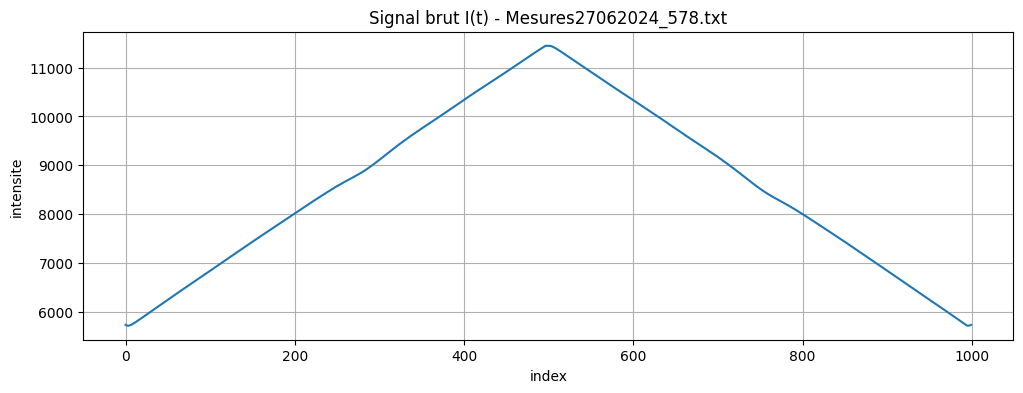

In [2]:
# [Guide] Étape 1: lecture d'un fichier laser brut et visualisation de I(t).

def read_signal(path: Path) -> np.ndarray:
    """Lit un scan .txt et renvoie l'intensité I(t) en numpy array float."""
    values = []
    with path.open('r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            try:
                values.append(float(s.replace(',', '.')))
            except ValueError:
                continue
    return np.array(values, dtype=float)

example_path = DATA_DIR / 'Mesures27062024_578.txt'
print(Path.cwd())
I = read_signal(example_path)
t = np.arange(I.size)

print('Fichier:', example_path.name, '| N =', I.size)

plt.figure(figsize=(12, 4))
plt.plot(t, I)
plt.title(f'Signal brut I(t) - {example_path.name}')
plt.xlabel('index')
plt.ylabel('intensite')
plt.grid(True)
plt.show()

# Evite la re-affichage de figures plus tard dans le notebook
plt.close('all')


## 2) Baseline `I0(t)` et absorbance `A(t)`

Methode:
- pic global `p = argmax(I)`
- points "propres" via lissage leger
- fit de 2 droites (gauche/droite)
- jonction a l'intersection
- contrainte `I0 >= I` (pas d'absorbance negative)


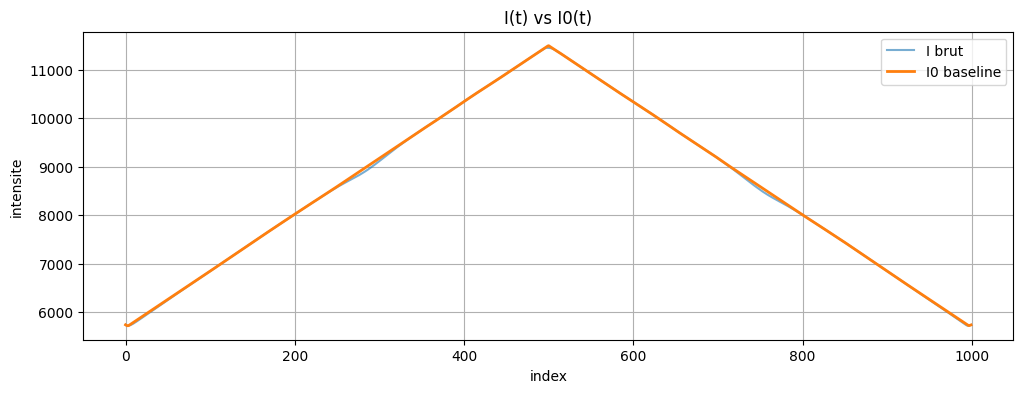

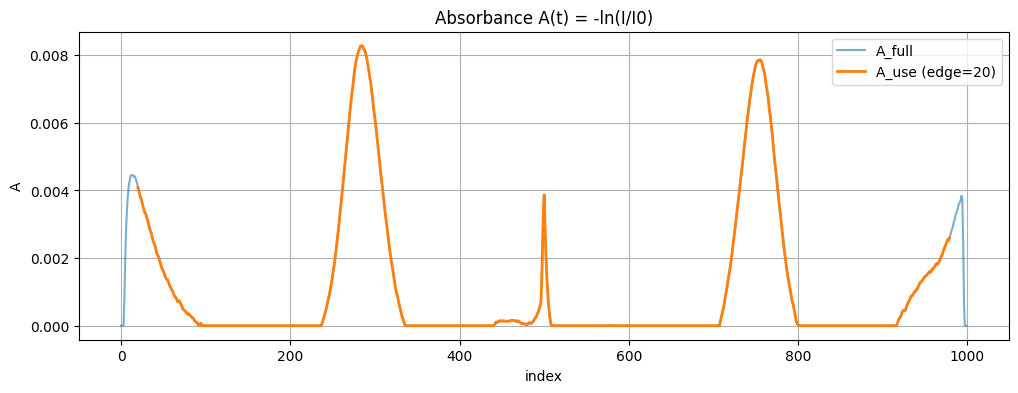

A_full min/max: -0.0 0.008280580615353965


In [3]:
# [Guide] Étape 2: construction de la baseline I0(t), puis calcul de A(t).

def moving_average_reflect(x: np.ndarray, window: int) -> np.ndarray:
    """Lissage simple avec padding miroir pour éviter les artefacts de bord."""
    if window % 2 == 0:
        raise ValueError('window must be odd')
    pad = window // 2
    x_pad = np.pad(x, pad_width=pad, mode='reflect')
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(x_pad, kernel, mode='valid')


def compute_I0(I: np.ndarray, smooth_window: int = 41, k: float = 0.20) -> np.ndarray:
    """Construit la baseline triangulaire I0(t) avec 2 régressions linéaires."""
    t = np.arange(I.size, dtype=float)
    p = int(np.argmax(I))

    I_s = moving_average_reflect(I, smooth_window)
    D = I_s - I
    thr = np.quantile(D, 1 - k)
    good = D < thr

    left = (t <= p) & good
    right = (t >= p) & good
    if left.sum() < 10 or right.sum() < 10:
        raise ValueError('Not enough points for robust baseline fit.')

    coef_left = np.polyfit(t[left], I[left], deg=1)
    coef_right = np.polyfit(t[right], I[right], deg=1)

    m1, b1 = coef_left
    m2, b2 = coef_right
    if abs(m1 - m2) < 1e-12:
        p_join = p
    else:
        t_star = (b2 - b1) / (m1 - m2)
        p_join = int(np.clip(round(t_star), 1, I.size - 2))

    I0_left = np.polyval(coef_left, t)
    I0_right = np.polyval(coef_right, t)

    I0 = np.empty_like(I, dtype=float)
    I0[:p_join] = I0_left[:p_join]
    I0[p_join:] = I0_right[p_join:]
    I0 = np.maximum(I0, I)
    return I0


def compute_A_full(I: np.ndarray, I0: np.ndarray) -> np.ndarray:
    """Applique A(t) = -ln(I/I0) avec clipping numérique stable."""
    eps = 1e-9
    return -np.log(np.clip(I, eps, None) / np.clip(I0, eps, None))


I0 = compute_I0(I, smooth_window=41, k=0.20)
A_full = compute_A_full(I, I0)

plt.figure(figsize=(12, 4))
plt.plot(t, I, label='I brut', alpha=0.6)
plt.plot(t, I0, label='I0 baseline', linewidth=2)
plt.title('I(t) vs I0(t)')
plt.xlabel('index')
plt.ylabel('intensite')
plt.grid(True)
plt.legend()
plt.show()

edge = 20
A_use = A_full[edge:-edge] if A_full.size > 2 * edge else A_full
plt.figure(figsize=(12, 4))
plt.plot(t, A_full, label='A_full', alpha=0.6)
plt.plot(np.arange(edge, edge + A_use.size), A_use, label=f'A_use (edge={edge})', linewidth=2)
plt.title('Absorbance A(t) = -ln(I/I0)')
plt.xlabel('index')
plt.ylabel('A')
plt.grid(True)
plt.legend()
plt.show()

print('A_full min/max:', float(A_full.min()), float(A_full.max()))

# Evite la re-affichage de figures plus tard dans le notebook
plt.close('all')


## 3) Features robustes (plus stables que l'aire totale seule)

Features calculees:
- `F_area_total`, `F_mean`
- `F_p95`, `F_p99`
- `F_top10_area` (aire au-dessus du q90)
- features sur ROI principale (`F_main_roi_*`)


In [4]:
# [Guide] Étape 3: extraction de features robustes depuis A(t).

def _contiguous_true_runs(mask: np.ndarray) -> list[tuple[int, int]]:
    """Retourne les segments contigus où le masque booléen vaut True."""
    if not np.any(mask):
        return []
    idx = np.flatnonzero(mask)
    splits = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, splits)
    return [(int(g[0]), int(g[-1]) + 1) for g in groups if g.size > 0]


def extract_features(A_full: np.ndarray, edge: int = 20) -> dict[str, float]:
    """Extrait des features robustes: quantiles, aire haute, ROI principale."""
    A_use = A_full[edge:-edge] if A_full.size > 2 * edge else A_full
    if A_use.size == 0:
        A_use = A_full

    q90 = float(np.quantile(A_use, 0.90))
    q95 = float(np.quantile(A_use, 0.95))
    q99 = float(np.quantile(A_use, 0.99))

    high_mask = A_use >= q90
    runs = _contiguous_true_runs(high_mask)

    if runs:
        run_scores = [float(np.sum(A_use[s:e] - q90)) for s, e in runs]
        best = int(np.argmax(run_scores))
        s0, e0 = runs[best]
        pad = 12
        s1 = max(0, s0 - pad)
        e1 = min(A_use.size, e0 + pad)
        roi = A_use[s1:e1]
    else:
        roi = A_use

    return {
        'F_area_total': float(np.sum(A_use)),
        'F_mean': float(np.mean(A_use)),
        'F_p95': q95,
        'F_p99': q99,
        'F_top10_area': float(np.sum(np.clip(A_use - q90, 0, None))),
        'F_main_roi_area': float(np.sum(roi)),
        'F_main_roi_mean': float(np.mean(roi)),
        'F_main_roi_peak': float(np.max(roi)),
    }

print('Features exemple:')
extract_features(A_full)


Features exemple:


{'F_area_total': 0.9940250901109068,
 'F_mean': 0.0010354428021988613,
 'F_p95': 0.006656850739371314,
 'F_p99': 0.00800472237982545,
 'F_top10_area': 0.24240659697540018,
 'F_main_roi_area': 0.38039780851317195,
 'F_main_roi_mean': 0.005283302896016277,
 'F_main_roi_peak': 0.008280580615353965}

## 4) Calcul des features pour tous les scans (0 à 578)

In [5]:
# [Guide] Étape 4: calcul des features pour tous les scans (0..578).

def build_laser_features() -> pd.DataFrame:
    """Boucle sur tous les scans et construit le tableau de features laser."""
    paths = sorted(DATA_DIR.glob(SIGNAL_PATTERN), key=lambda p: int(p.stem.split('_')[-1]))
    if not paths:
        raise FileNotFoundError(f'No signal found under {DATA_DIR} with {SIGNAL_PATTERN}')

    rows = []
    # Boucle scan par scan: baseline -> absorbance -> features
    for p in paths:
        scan_id = int(p.stem.split('_')[-1])
        I = read_signal(p)
        I0 = compute_I0(I, smooth_window=41, k=0.20)
        A_full = compute_A_full(I, I0)
        feat = extract_features(A_full, edge=20)
        rows.append({'scan_id': scan_id, **feat})

    return pd.DataFrame(rows).sort_values('scan_id').reset_index(drop=True)


df_laser = build_laser_features()
print('df_laser shape:', df_laser.shape)
df_laser.head()


df_laser shape: (579, 9)


,scan_id,F_area_total,F_mean,F_p95,F_p99,F_top10_area,F_main_roi_area,F_main_roi_mean,F_main_roi_peak
0,0,0.973962,0.001015,0.004599,0.006788,0.162795,0.303512,0.004818,0.007640
1,1,1.009302,0.001051,0.005657,0.008147,0.250495,0.350006,0.005556,0.009382
2,2,0.907632,0.000945,0.004354,0.007257,0.170024,0.311633,0.004947,0.008407
3,3,1.005283,0.001047,0.004286,0.006859,0.129641,0.285574,0.005010,0.007740
4,4,0.947938,0.000987,0.004211,0.006199,0.123342,0.251832,0.004664,0.006884


## 5) Lecture propre du fichier bouton Excel (`.xlsx`)

Le parsing est fait sans `openpyxl` pour rester robuste dans cet environnement.


In [6]:
# [Guide] Étape 5: lecture du fichier bouton Excel (.xlsx) sans dépendance openpyxl.

def _excel_col_to_idx(col: str) -> int:
    """Convertit une colonne Excel (A, B, AA...) en index 0-based."""
    v = 0
    for ch in col:
        v = v * 26 + (ord(ch) - ord('A') + 1)
    return v - 1


def _parse_xlsx_sheet_1(path: Path) -> pd.DataFrame:
    """Parse sheet1 XML d'un .xlsx (sans openpyxl), en conservant les styles date/heure."""
    ns = {'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    with ZipFile(path) as z:
        shared = []
        if 'xl/sharedStrings.xml' in z.namelist():
            sroot = ET.fromstring(z.read('xl/sharedStrings.xml'))
            for si in sroot.findall('a:si', ns):
                text = ''.join(t.text or '' for t in si.findall('.//a:t', ns))
                shared.append(text)

        style_root = ET.fromstring(z.read('xl/styles.xml'))
        style_to_numfmt = []
        cellxfs = style_root.find('a:cellXfs', ns)
        if cellxfs is not None:
            for xf in cellxfs.findall('a:xf', ns):
                style_to_numfmt.append(int(xf.attrib.get('numFmtId', '0')))

        custom_numfmt = {}
        numfmts = style_root.find('a:numFmts', ns)
        if numfmts is not None:
            for numfmt in numfmts.findall('a:numFmt', ns):
                numfmt_id = int(numfmt.attrib['numFmtId'])
                custom_numfmt[numfmt_id] = (numfmt.attrib.get('formatCode') or '').lower()

        date_numfmt = {14, 15, 16, 17, 18, 19, 20, 21, 22, 45, 46, 47}
        date_style_ids = set()
        for style_id, numfmt_id in enumerate(style_to_numfmt):
            if numfmt_id in date_numfmt:
                date_style_ids.add(style_id)
                continue
            code = custom_numfmt.get(numfmt_id, '')
            if any(tok in code for tok in ['yy', 'dd', 'hh', 'ss']):
                date_style_ids.add(style_id)

        root = ET.fromstring(z.read('xl/worksheets/sheet1.xml'))
        rows = []
        max_col_idx = 0
        for row in root.findall('.//a:sheetData/a:row', ns):
            rid = int(row.attrib['r'])
            out = {'_row': rid}
            for cell in row.findall('a:c', ns):
                ref = cell.attrib['r']
                col = ''.join(ch for ch in ref if ch.isalpha())
                col_idx = _excel_col_to_idx(col)
                max_col_idx = max(max_col_idx, col_idx)

                style_id = int(cell.attrib.get('s', '0'))
                cell_type = cell.attrib.get('t')
                v = cell.find('a:v', ns)
                if v is None or v.text is None:
                    value = ''
                else:
                    txt = v.text
                    if cell_type == 's':
                        value = shared[int(txt)] if txt.isdigit() else txt
                    elif cell_type == 'b':
                        value = txt == '1'
                    else:
                        if style_id in date_style_ids:
                            try:
                                serial = float(txt)
                                value = pd.Timestamp('1899-12-30') + pd.to_timedelta(serial, unit='D')
                            except Exception:
                                value = txt
                        else:
                            try:
                                value = float(txt)
                            except ValueError:
                                value = txt
                out[col] = value
            rows.append(out)

    cols = []
    for idx in range(max_col_idx + 1):
        if idx < 26:
            cols.append(chr(ord('A') + idx))
        else:
            q = idx // 26 - 1
            r = idx % 26
            cols.append(chr(ord('A') + q) + chr(ord('A') + r))

    df = pd.DataFrame(rows)
    for c in cols:
        if c not in df.columns:
            df[c] = np.nan
    return df.sort_values('_row').reset_index(drop=True)


def read_button_log_xlsx(path: Path, header_row: int = 9) -> pd.DataFrame:
    """Lit le log bouton et renvoie btn_dt, T, HA_ref, Abs_ref, btn_idx."""
    if not path.exists():
        raise FileNotFoundError(path)

    raw = _parse_xlsx_sheet_1(path)
    header = raw.loc[raw['_row'] == header_row]
    if header.empty:
        raise ValueError(f'Header row {header_row} not found in {path}')
    header = header.iloc[0]

    rename_map = {}
    for col in raw.columns:
        if col == '_row':
            continue
        val = header.get(col, '')
        if pd.isna(val):
            continue
        name = str(val).strip()
        if name:
            rename_map[col] = name

    df = raw.loc[raw['_row'] > header_row].rename(columns=rename_map).copy()
    required = ['Date', 'Heure', 'Température', 'Ha (g/m3)', 'Absorbance']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing columns in button log: {missing}')

    date_col = df['Date']
    time_col = df['Heure']

    if pd.api.types.is_datetime64_any_dtype(time_col):
        date_str = pd.to_datetime(date_col, errors='coerce').dt.strftime('%d/%m/%Y')
    else:
        date_str = date_col.astype(str).str.strip()

    if pd.api.types.is_datetime64_any_dtype(time_col):
        time_str = pd.to_datetime(time_col, errors='coerce').dt.strftime('%H:%M:%S')
    else:
        time_str = time_col.astype(str).str.strip()
        has_date = time_str.str.contains(' ', na=False)
        if has_date.any():
            time_str.loc[has_date] = pd.to_datetime(time_str.loc[has_date], errors='coerce').dt.strftime('%H:%M:%S')

    dt = pd.to_datetime(date_str + ' ' + time_str, dayfirst=True, errors='coerce')

    out = pd.DataFrame({
        'btn_dt': dt,
        'T': pd.to_numeric(df['Température'], errors='coerce'),
        'HA_ref': pd.to_numeric(df['Ha (g/m3)'], errors='coerce'),
        'Abs_ref': pd.to_numeric(df['Absorbance'], errors='coerce'),
    })
    out = out.dropna(subset=['btn_dt', 'T', 'HA_ref', 'Abs_ref']).reset_index(drop=True)
    out['btn_idx'] = np.arange(len(out))
    return out


def read_summary(path: Path) -> pd.DataFrame:
    """Lit le fichier summary (timestamp + absorbance de référence)."""
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path, sep='	', header=None, names=['scan_dt', 'summary_abs'])
    df['scan_dt'] = pd.to_datetime(df['scan_dt'], format='%d.%m.%Y %H:%M:%S')
    df['summary_abs'] = pd.to_numeric(df['summary_abs'], errors='coerce')
    df['scan_id'] = np.arange(len(df))
    return df.dropna(subset=['scan_dt', 'summary_abs']).reset_index(drop=True)


df_btn = read_button_log_xlsx(XLSX_PATH, header_row=9)
df_summary = read_summary(SUMMARY_PATH)

print('df_btn:', df_btn.shape, '| time:', df_btn['btn_dt'].min(), '->', df_btn['btn_dt'].max())
print('df_summary:', df_summary.shape, '| time:', df_summary['scan_dt'].min(), '->', df_summary['scan_dt'].max())
df_btn.head()


df_btn: (575, 5) | time: 2024-06-27 11:16:01 -> 2024-06-27 14:27:21
df_summary: (579, 3) | time: 2024-06-27 11:15:00 -> 2024-06-27 14:27:25


,btn_dt,T,HA_ref,Abs_ref,btn_idx
0,2024-06-27 11:16:01,19.4,5.606579,0.002107,0
1,2024-06-27 11:16:21,19.6,5.385838,0.001615,1
2,2024-06-27 11:16:41,19.7,5.536421,0.001740,2
3,2024-06-27 11:17:01,19.8,5.295660,0.001650,3
4,2024-06-27 11:17:21,19.9,5.189317,0.001951,4


## 6) Matching scan <-> bouton

On compare 3 strategies:
- index + shift (`btn_idx = scan_id + shift`)
- alignement temporel (`merge_asof`)
- DTW (fallback)


In [7]:
# [Guide] Étape 6: fonctions utilitaires pour le matching scan <-> bouton.

def corr_safe(x: pd.Series, y: pd.Series) -> float:
    """Corrélation robuste avec gestion NaN et cas dégénérés."""
    x = pd.to_numeric(x, errors='coerce')
    y = pd.to_numeric(y, errors='coerce')
    mask = x.notna() & y.notna()
    if mask.sum() < 10:
        return float('nan')
    xx = x[mask].to_numpy(dtype=float)
    yy = y[mask].to_numpy(dtype=float)
    if np.std(xx) < 1e-12 or np.std(yy) < 1e-12:
        return float('nan')
    return float(np.corrcoef(xx, yy)[0, 1])


def compute_feature_correlations(aligned: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Calcule corr(feature, HA_ref) et corr(feature, Abs_ref) pour chaque feature."""
    rows = []
    for feat in feature_cols:
        sub = aligned[[feat, 'HA_ref', 'Abs_ref']].dropna()
        if len(sub) < 10:
            continue
        rows.append({
            'feature': feat,
            'corr_HA': corr_safe(sub[feat], sub['HA_ref']),
            'corr_Abs': corr_safe(sub[feat], sub['Abs_ref']),
            'n': int(len(sub)),
        })
    return pd.DataFrame(rows)


def mapping_score(corr_df: pd.DataFrame) -> float:
    """Score de matching: médiane |corr_HA| + 0.5 * médiane |corr_Abs|."""
    if corr_df.empty:
        return float('-inf')
    return float(corr_df['corr_HA'].abs().median() + 0.5 * corr_df['corr_Abs'].abs().median())


def align_by_shift(df_laser: pd.DataFrame, df_btn: pd.DataFrame, shift: int) -> pd.DataFrame:
    """Aligne par index avec btn_idx = scan_id + shift."""
    tmp = df_laser.copy()
    tmp['btn_idx'] = tmp['scan_id'] + shift
    out = tmp.merge(df_btn, on='btn_idx', how='inner')
    return out.sort_values('scan_id').reset_index(drop=True)


def evaluate_shift_candidates(df_laser: pd.DataFrame, df_btn: pd.DataFrame, feature_cols: list[str],
                              shift_min: int = -40, shift_max: int = 40):
    """Teste une grille de décalages et retourne le meilleur alignement indexé."""
    rows = []
    best_shift = 0
    best_score = float('-inf')
    best_aligned = pd.DataFrame()
    best_corr = pd.DataFrame()

    # On teste chaque décalage possible et on garde le meilleur score
    for shift in range(shift_min, shift_max + 1):
        aligned = align_by_shift(df_laser, df_btn, shift)
        corr_df = compute_feature_correlations(aligned, feature_cols)
        score = mapping_score(corr_df)
        if corr_df.empty:
            continue
        best_row = corr_df.iloc[corr_df['corr_HA'].abs().idxmax()]
        rows.append({
            'shift': shift,
            'score': score,
            'n_pairs': int(len(aligned)),
            'best_feature_HA': best_row['feature'],
            'best_corr_HA': best_row['corr_HA'],
            'best_corr_Abs': best_row['corr_Abs'],
        })

        if score > best_score:
            best_score = score
            best_shift = shift
            best_aligned = aligned
            best_corr = corr_df

    return pd.DataFrame(rows), best_shift, best_aligned, best_corr


def validate_shift_with_summary(df_summary: pd.DataFrame, df_btn: pd.DataFrame,
                                shift_min: int = -20, shift_max: int = 20):
    """Valide le shift via corrélation summary_abs <-> Abs_ref (référence externe)."""
    best_shift = 0
    best_corr = float('nan')
    best_n = 0
    # On teste chaque décalage possible et on garde le meilleur score
    for shift in range(shift_min, shift_max + 1):
        tmp = df_summary.copy()
        tmp['btn_idx'] = tmp['scan_id'] - shift
        merged = tmp.merge(df_btn[['btn_idx', 'Abs_ref']], on='btn_idx', how='inner')
        corr = corr_safe(merged['summary_abs'], merged['Abs_ref'])
        if np.isnan(corr):
            continue
        if np.isnan(best_corr) or abs(corr) > abs(best_corr):
            best_shift = shift
            best_corr = corr
            best_n = len(merged)
    return best_shift, best_corr, best_n


def align_by_time(df_laser: pd.DataFrame, df_btn: pd.DataFrame, df_summary: pd.DataFrame, tol_s: int = 12):
    """Aligne par proximité temporelle (merge_asof) avec tolérance en secondes."""
    scan = df_laser.merge(df_summary[['scan_id', 'scan_dt']], on='scan_id', how='inner').sort_values('scan_dt')
    btn = df_btn.sort_values('btn_dt')

    merged = pd.merge_asof(
        scan, btn,
        left_on='scan_dt', right_on='btn_dt',
        direction='nearest', tolerance=pd.Timedelta(seconds=tol_s)
    )
    merged = merged.dropna(subset=['btn_idx']).copy()
    merged['btn_idx'] = merged['btn_idx'].astype(int)
    merged['time_err_s'] = (merged['scan_dt'] - merged['btn_dt']).dt.total_seconds().abs()
    merged = merged.sort_values(['btn_idx', 'time_err_s']).drop_duplicates('btn_idx', keep='first')
    return merged.sort_values('scan_id').reset_index(drop=True)


def _zscore(x: np.ndarray) -> np.ndarray:
    """Standardisation (x - moyenne) / ecart-type."""
    mu = float(np.mean(x))
    sd = float(np.std(x))
    if sd < 1e-12:
        return np.zeros_like(x)
    return (x - mu) / sd


def dtw_path(x: np.ndarray, y: np.ndarray, window: int | None = None):
    """Calcule le chemin DTW (Dynamic Time Warping) avec fenêtre de Sakoe-Chiba."""
    n = len(x)
    m = len(y)
    if window is None:
        window = max(n, m)
    window = max(window, abs(n - m))

    D = np.full((n + 1, m + 1), np.inf, dtype=float)
    D[0, 0] = 0.0

    for i in range(1, n + 1):
        j_start = max(1, i - window)
        j_end = min(m, i + window)
        for j in range(j_start, j_end + 1):
            cost = (x[i - 1] - y[j - 1]) ** 2
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])

    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        prev = np.argmin([D[i - 1, j - 1], D[i - 1, j], D[i, j - 1]])
        if prev == 0:
            i -= 1
            j -= 1
        elif prev == 1:
            i -= 1
        else:
            j -= 1

    while i > 0:
        i -= 1
        path.append((i, 0))
    while j > 0:
        j -= 1
        path.append((0, j))

    path.reverse()
    return path


def align_by_dtw(df_laser: pd.DataFrame, df_btn: pd.DataFrame, feature_col: str = 'F_p95', window: int = 35):
    """Aligne scan->bouton via DTW (utilisé surtout en diagnostic/fallback)."""
    scan = df_laser.sort_values('scan_id').reset_index(drop=True).copy()
    btn = df_btn.sort_values('btn_idx').reset_index(drop=True).copy()

    x = _zscore(scan[feature_col].to_numpy(dtype=float))
    y = _zscore(btn['HA_ref'].to_numpy(dtype=float))
    path = dtw_path(x, y, window=window)

    pairs = pd.DataFrame(path, columns=['scan_pos', 'btn_pos'])
    map_pos = pairs.groupby('scan_pos', as_index=False)['btn_pos'].median().round().astype(int)
    map_pos['btn_pos'] = map_pos['btn_pos'].clip(lower=0, upper=len(btn) - 1)

    scan['scan_pos'] = np.arange(len(scan))
    scan = scan.merge(map_pos, on='scan_pos', how='left')
    scan['btn_idx'] = scan['btn_pos'].fillna(0).astype(int)

    aligned = scan.merge(btn, on='btn_idx', how='inner')
    return aligned.sort_values('scan_id').reset_index(drop=True)


In [8]:
# [Guide] Test des 3 approches de matching: shift index, alignement temporel, DTW.

feature_cols = [c for c in df_laser.columns if c != 'scan_id']

# 1) index + shift
shift_scores, best_shift, aligned_shift, corr_shift = evaluate_shift_candidates(
    df_laser, df_btn, feature_cols, shift_min=-40, shift_max=40
)

# 2) time-nearest
aligned_time = align_by_time(df_laser, df_btn, df_summary, tol_s=12)
corr_time = compute_feature_correlations(aligned_time, feature_cols)
score_time = mapping_score(corr_time)

# 3) DTW fallback
aligned_dtw = align_by_dtw(df_laser, df_btn, feature_col='F_p95', window=35)
corr_dtw = compute_feature_correlations(aligned_dtw, feature_cols)
score_dtw = mapping_score(corr_dtw)

# Validation externe avec summary
summary_shift, summary_corr, summary_n = validate_shift_with_summary(df_summary, df_btn, -20, 20)

print('best_shift (index score) =', best_shift)
print('summary validation shift =', summary_shift, '| corr =', round(summary_corr, 6), '| n =', summary_n)
print('score_time =', round(score_time, 6), '| score_dtw =', round(score_dtw, 6))

shift_scores.sort_values('score', ascending=False).head(10)


best_shift (index score) = -4
summary validation shift = 4 | corr = 1.0 | n = 575
score_time = 1.47951 | score_dtw = 1.482873


,shift,score,n_pairs,best_feature_HA,best_corr_HA,best_corr_Abs
36,-4,1.479510,575,F_p95,0.993142,0.991446
35,-5,1.474988,574,F_p95,0.990708,0.987865
37,-3,1.474963,575,F_p95,0.989961,0.988103
34,-6,1.471008,573,F_p95,0.988579,0.984817
38,-2,1.469870,575,F_p95,0.985759,0.986120
33,-7,1.466655,572,F_p95,0.986411,0.981478
39,-1,1.465302,575,F_p95,0.982792,0.983580
40,0,1.459778,575,F_p95,0.978590,0.980186
32,-8,1.458904,571,F_p95,0.981740,0.976998
41,1,1.452586,574,F_p95,0.972871,0.975916


In [9]:
# [Guide] Sélection de la stratégie de matching finale et de la meilleure feature laser.

# Choix final du matching
if abs(summary_corr) >= 0.98:
    final_shift = -summary_shift
    aligned_final = align_by_shift(df_laser, df_btn, final_shift)
    corr_final = compute_feature_correlations(aligned_final, feature_cols)
    final_method = f'index_shift_from_summary({final_shift})'
else:
    candidates = [
        ('index_shift', mapping_score(corr_shift), aligned_shift, corr_shift),
        ('time_nearest', score_time, aligned_time, corr_time),
        ('dtw', score_dtw, aligned_dtw, corr_dtw),
    ]
    final_method, _, aligned_final, corr_final = max(candidates, key=lambda x: x[1])
    final_shift = best_shift

best_feature_row = corr_final.iloc[corr_final['corr_HA'].abs().idxmax()]
best_feature = str(best_feature_row['feature'])

print('final_method =', final_method)
print('final_pairs =', len(aligned_final))
print('best_feature =', best_feature)
print('corr(best_feature, HA_ref) =', round(float(best_feature_row['corr_HA']), 6))

corr_final.sort_values('corr_HA', key=lambda s: s.abs(), ascending=False)


final_method = index_shift_from_summary(-4)
final_pairs = 575
best_feature = F_p95
corr(best_feature, HA_ref) = 0.993142


,feature,corr_HA,corr_Abs,n
2,F_p95,0.993142,0.991446,575
6,F_main_roi_mean,0.989802,0.987421,575
3,F_p99,0.988917,0.989699,575
7,F_main_roi_peak,0.988196,0.988455,575
1,F_mean,0.985473,0.978587,575
0,F_area_total,0.985473,0.978587,575
5,F_main_roi_area,0.978966,0.980715,575
4,F_top10_area,0.973684,0.983280,575


## 7) Calibration `HA_ref ~ feature` et `HA_ref ~ feature + T`

Split chronologique:
- train = 70% debut
- test = 30% fin


In [10]:
# [Guide] Étape 7: calibration linéaire HA_ref ~ feature (avec/sans T) et métriques.

def fit_linear_model(df: pd.DataFrame, x_cols: list[str], y_col: str = 'HA_ref'):
    """Ajuste une régression linéaire par moindres carrés."""
    X = np.column_stack([np.ones(len(df))] + [df[c].to_numpy(dtype=float) for c in x_cols])
    y = df[y_col].to_numpy(dtype=float)
    coef = np.linalg.lstsq(X, y, rcond=None)[0]
    y_pred = X @ coef
    return coef, y_pred


def metrics(y_true: np.ndarray, y_pred: np.ndarray):
    """Retourne RMSE, MAE et R2."""
    err = y_true - y_pred
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(err)))
    den = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1 - np.sum(err ** 2) / den) if den > 0 else float('nan')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}


def run_calibration(aligned: pd.DataFrame, feature_col: str):
    """Évalue les modèles sur split chronologique: train 70% début, test 30% fin."""
    data = aligned.sort_values('scan_id')[[feature_col, 'T', 'HA_ref', 'scan_id']].dropna().reset_index(drop=True)
    n = len(data)
    cut = int(0.7 * n)
    train = data.iloc[:cut].copy()
    test = data.iloc[cut:].copy()

    models = {
        'HA ~ feature': [feature_col],
        'HA ~ feature + T': [feature_col, 'T'],
    }

    metrics_rows = []
    pred_rows = []

    # Deux variantes de modèle: sans T, puis avec T
    for model_name, cols in models.items():
        coef_all, pred_all = fit_linear_model(data, cols, y_col='HA_ref')
        coef_train, pred_train = fit_linear_model(train, cols, y_col='HA_ref')

        X_test = np.column_stack([np.ones(len(test))] + [test[c].to_numpy(dtype=float) for c in cols])
        pred_test = X_test @ coef_train

        m_all = metrics(data['HA_ref'].to_numpy(dtype=float), pred_all)
        m_train = metrics(train['HA_ref'].to_numpy(dtype=float), pred_train)
        m_test = metrics(test['HA_ref'].to_numpy(dtype=float), pred_test)

        metrics_rows.append({
            'model': model_name,
            'split': 'all',
            'n': len(data),
            **m_all,
            'coef_intercept': float(coef_all[0]),
            'coef_feature': float(coef_all[1]) if len(coef_all) > 1 else np.nan,
            'coef_T': float(coef_all[2]) if len(coef_all) > 2 else np.nan,
            'feature_col': feature_col,
        })
        metrics_rows.append({
            'model': model_name,
            'split': 'train_70',
            'n': len(train),
            **m_train,
            'coef_intercept': float(coef_train[0]),
            'coef_feature': float(coef_train[1]) if len(coef_train) > 1 else np.nan,
            'coef_T': float(coef_train[2]) if len(coef_train) > 2 else np.nan,
            'feature_col': feature_col,
        })
        metrics_rows.append({
            'model': model_name,
            'split': 'test_30',
            'n': len(test),
            **m_test,
            'coef_intercept': float(coef_train[0]),
            'coef_feature': float(coef_train[1]) if len(coef_train) > 1 else np.nan,
            'coef_T': float(coef_train[2]) if len(coef_train) > 2 else np.nan,
            'feature_col': feature_col,
        })

        if model_name == 'HA ~ feature + T':
            pred_rows.append(pd.DataFrame({
                'scan_id': test['scan_id'].to_numpy(dtype=int),
                'HA_ref': test['HA_ref'].to_numpy(dtype=float),
                'HA_pred': pred_test.astype(float),
                'residual': (test['HA_ref'].to_numpy(dtype=float) - pred_test).astype(float),
                'model': model_name,
            }))

    metrics_df = pd.DataFrame(metrics_rows)
    pred_df = pd.concat(pred_rows, ignore_index=True)
    return metrics_df, pred_df


calib_metrics, calib_pred = run_calibration(aligned_final, best_feature)
calib_metrics


,model,split,n,rmse,mae,r2,coef_intercept,coef_feature,coef_T,feature_col
0,HA ~ feature,all,575,1.701688,1.291631,0.986331,-1.958283,1669.539607,NaN,F_p95
1,HA ~ feature,train_70,402,1.551777,1.204216,0.981388,-1.238355,1598.842872,NaN,F_p95
2,HA ~ feature,test_30,173,2.403133,1.738950,0.981263,-1.238355,1598.842872,NaN,F_p95
3,HA ~ feature + T,all,575,1.699942,1.293189,0.986359,-1.210012,1684.694609,-0.025334,F_p95
4,HA ~ feature + T,train_70,402,1.533954,1.194529,0.981813,-3.486942,1537.121084,0.082961,F_p95
5,HA ~ feature + T,test_30,173,2.583666,1.868931,0.978342,-3.486942,1537.121084,0.082961,F_p95


## 8) Plots de controle

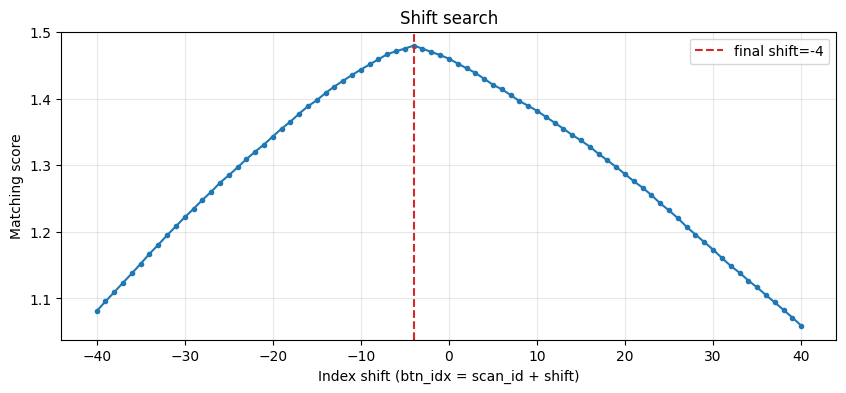

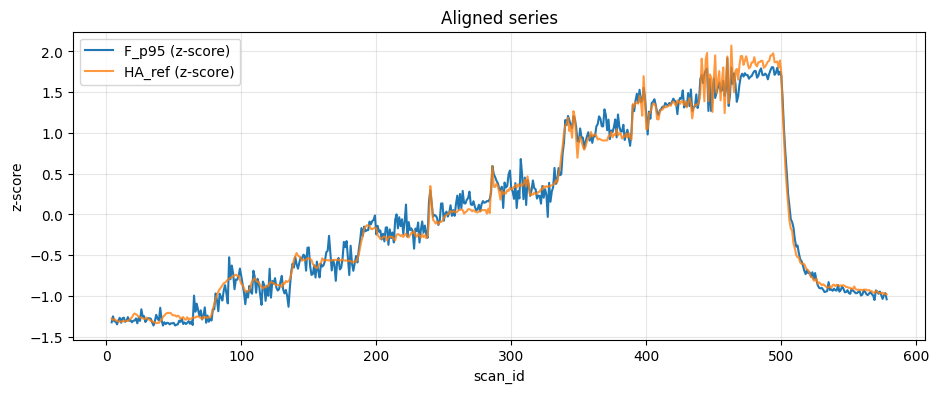

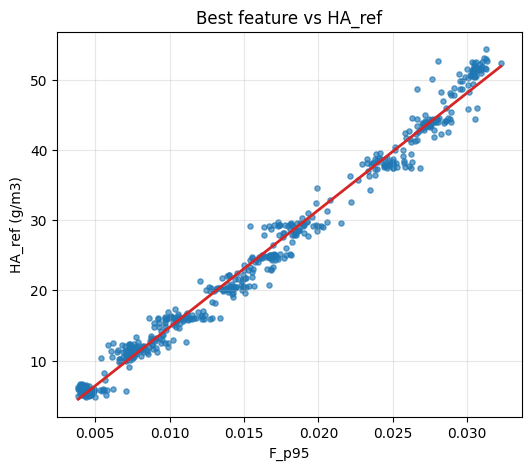

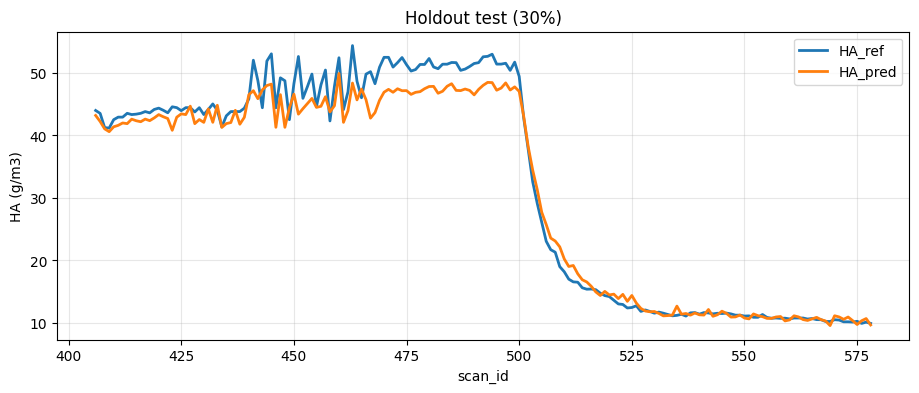

In [11]:
# [Guide] Étape 8: plots de contrôle pour valider matching et calibration.

# Score shifts
plt.figure(figsize=(10, 4))
plt.plot(shift_scores['shift'], shift_scores['score'], marker='o', ms=3)
plt.axvline(final_shift, color='tab:red', linestyle='--', label=f'final shift={final_shift}')
plt.xlabel('Index shift (btn_idx = scan_id + shift)')
plt.ylabel('Matching score')
plt.title('Shift search')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Timeline z-score
a = aligned_final.sort_values('scan_id')
x = a['scan_id'].to_numpy(dtype=int)
y1 = _zscore(a[best_feature].to_numpy(dtype=float))
y2 = _zscore(a['HA_ref'].to_numpy(dtype=float))
plt.figure(figsize=(11, 4))
plt.plot(x, y1, label=f'{best_feature} (z-score)')
plt.plot(x, y2, label='HA_ref (z-score)', alpha=0.8)
plt.xlabel('scan_id')
plt.ylabel('z-score')
plt.title('Aligned series')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Scatter feature -> HA
x_feat = a[best_feature].to_numpy(dtype=float)
y_ha = a['HA_ref'].to_numpy(dtype=float)
slope, intercept = np.polyfit(x_feat, y_ha, deg=1)
xx = np.linspace(np.min(x_feat), np.max(x_feat), 200)
yy = slope * xx + intercept
plt.figure(figsize=(6, 5))
plt.scatter(x_feat, y_ha, s=14, alpha=0.65)
plt.plot(xx, yy, color='tab:red', linewidth=2)
plt.xlabel(best_feature)
plt.ylabel('HA_ref (g/m3)')
plt.title('Best feature vs HA_ref')
plt.grid(True, alpha=0.3)
plt.show()

# Holdout predictions
p = calib_pred.sort_values('scan_id')
plt.figure(figsize=(11, 4))
plt.plot(p['scan_id'], p['HA_ref'], label='HA_ref', linewidth=2)
plt.plot(p['scan_id'], p['HA_pred'], label='HA_pred', linewidth=2)
plt.xlabel('scan_id')
plt.ylabel('HA (g/m3)')
plt.title('Holdout test (30%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Evite la re-affichage de figures plus tard dans le notebook
plt.close('all')


## 9) Export des resultats

Les CSV/figures sont sauvegardes pour reutilisation dans d'autres notebooks/scripts.


In [12]:
# [Guide] Étape 9: export des CSV finaux pour analyse/reprise.

# Exports CSV
run_summary = pd.DataFrame([{
    'n_scans': len(df_laser),
    'n_button_rows': len(df_btn),
    'n_summary_rows': len(df_summary),
    'best_shift_index_score': best_shift,
    'summary_validated_shift': summary_shift,
    'summary_corr_absorbance': summary_corr,
    'summary_pairs': summary_n,
    'final_method': final_method,
    'final_shift_used': final_shift,
    'final_pairs': len(aligned_final),
    'best_feature': best_feature,
    'best_corr_HA': float(best_feature_row['corr_HA']),
    'best_corr_Abs': float(best_feature_row['corr_Abs']),
}])

shift_scores.to_csv(OUT_REP_DIR / 'matching_shift_scores.csv', index=False)
corr_final.sort_values('corr_HA', key=lambda s: s.abs(), ascending=False).to_csv(
    OUT_REP_DIR / 'matching_feature_correlations.csv', index=False
)
calib_metrics.to_csv(OUT_REP_DIR / 'calibration_metrics.csv', index=False)
calib_pred.to_csv(OUT_REP_DIR / 'calibration_holdout_predictions.csv', index=False)
df_laser.to_csv(OUT_REP_DIR / 'laser_features_all_scans.csv', index=False)
aligned_final.to_csv(OUT_REP_DIR / 'aligned_laser_button.csv', index=False)
run_summary.to_csv(OUT_REP_DIR / 'laser_matching_run_summary.csv', index=False)

print('Saved reports in', OUT_REP_DIR)
print(run_summary.T)


Saved reports in outputs/reports
                                                    0
n_scans                                           579
n_button_rows                                     575
n_summary_rows                                    579
best_shift_index_score                             -4
summary_validated_shift                             4
summary_corr_absorbance                           1.0
summary_pairs                                     575
final_method             index_shift_from_summary(-4)
final_shift_used                                   -4
final_pairs                                       575
best_feature                                    F_p95
best_corr_HA                                 0.993142
best_corr_Abs                                0.991446


## 10) Notes pour travailler dessus

Pour tester rapidement les idees:
1. Modifier uniquement `extract_features(...)`
2. Relancer cellules 4 -> 9
3. Comparer `matching_feature_correlations.csv` et `calibration_metrics.csv`

Regle pratique:
- prioriser metriques `test_30` (pas `all`) pour eviter le sur-optimisme.
